In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00:00:01:00:01


In [1]:
import requests
import re
import urllib.parse
import json
import ast
import json
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from html.parser import HTMLParser
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    log_loss, confusion_matrix, classification_report, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier, Pool

ModuleNotFoundError: No module named 'catboost'

In [ ]:
TOKEN = "YOUR_GITHUB_TOKEN"
HEADERS = {"Authorization": f"Bearer {TOKEN}"}

In [ ]:
query = "gettext language:Python"
safe_query = urllib.parse.quote_plus(query)
PER_PAGE = 100
MAX_ITERATION = 10

In [ ]:
dataset = []

In [ ]:
for i in tqdm(range(10)):
    url = f"https://api.github.com/search/code?q={safe_query}&per_page={PER_PAGE}&page={i+1}"
    response = requests.get(url, headers=HEADERS)
    files = response.json()['items']
    if len(files) == 0:
        break

    for j in range(PER_PAGE):
        url = files[j]['html_url']
        raw_url = url.replace('github.com', 'raw.githubusercontent.com')
        raw_url = raw_url.replace('/blob/', '/')
        response = requests.get(raw_url)
        text = response.text

        dataset.append({
            'url': url,
            'file': text,
            'need': "import gettext" in text.lower()
        })

100%|██████████| 10/10 [11:32<00:00, 69.24s/it]


In [ ]:
with open("dataset.json", "r") as file:
    need_dataset = json.loads(file.read())

In [ ]:
need_dataset = [d for d in dataset if d['need']]

In [ ]:
with open("dataset.json", "w") as file:
    file.write(json.dumps(need_dataset))

In [ ]:
class GettextError(Exception):
    pass

class UnknownCallFuncClass(GettextError):
    pass

In [ ]:
def convert_py2_to_py3(code: str, remove_leading_zeros=False) -> str:
    """
    Преобразует print в стиле Python 2 в print-функцию Python 3.
    Также преобразует пустые print в print().
    Преобразует except Exception, e: в except Exception as e:
    Преобразует числа с ведущими нулями в явные восьмеричные
    или убирает их (если remove_leading_zeros=True).
    Не затрагивает числа с плавающей точкой!
    Сохраняет отступы!
    """

    # 0. Пустой print (print без аргументов)
    pattern_print_empty = re.compile(
        r'(?m)^([ \t]*)print\s*$'
    )
    code = pattern_print_empty.sub(r'\1print()', code)

    # 1. Преобразуем print c аргументами (но не с уже открытой скобкой)
    pattern_print = re.compile(
        r'(?m)^([ \t]*)print\s+(?!\()(.+)$'
    )
    def repl_print(m):
        indent = m.group(1)
        arg = m.group(2)
        return f'{indent}print({arg.strip()})'
    code = pattern_print.sub(repl_print, code)

    # 2. Преобразуем except Exception, e:
    pattern_except = re.compile(
        r'(?m)^([ \t]*)except\s+([a-zA-Z_][\w\.]*)(\s*,\s*([a-zA-Z_][\w]*))\s*:'
    )
    def repl_except(m):
        indent = m.group(1)
        exc_type = m.group(2)
        exc_var = m.group(4)
        return f'{indent}except {exc_type} as {exc_var}:'
    code = pattern_except.sub(repl_except, code)

    pattern_oct = re.compile(r'(?<![\w.])0([0-7]+)\b')
    code = pattern_oct.sub(r'0o\1', code)

    pattern_zero = re.compile(r'(?<![\w.])0([1-9]\d*)\b')
    code = pattern_zero.sub(r'\1', code)

    return code

In [ ]:
class GettextFinder(ast.NodeVisitor):
    DEFAULT_GETTEXT = 'gettext'
    DEFAULT_GETTEXT_FUNC = [DEFAULT_GETTEXT, 'gettext_lazy']
    GETTEXT_MODULE_FUNC = (
        'dgettext', 'dngettext', 'gettext', 'lgettext', 'ldgettext',
        'ldngettext', 'lngettext', 'ngettext',
        'pgettext', 'dpgettext', 'npgettext', 'dnpgettext', 'ugettext'
    )
    GETTEXT_FUNC_ARG_NUMBER = {
        'dgettext': 1,
    }
    GETTEXT_LANGUAGE_FUNC = 'language'

    def __init__(self):
        self.func_names = set()
        self.module_aliases = set()
        self.dataset = {}
        self.formats = []
        self.mods = []
        self.language_vars = set()

    def check_gettext(self, word):
        if word in self.DEFAULT_GETTEXT_FUNC:
            return True
        return self.DEFAULT_GETTEXT in word

    def process_format(self, node):
        base_node = node.func.value
        if self.is_gettext_name_func(base_node) and len(base_node.args) > 0:
            if not isinstance(base_node.args[0], ast.Constant):
                raise GettextError()
            value = base_node.args[0].value
            self.dataset[value]['with_format'] = True
        elif self.is_gettext_attr_func(base_node):
            raise GettextError()

    def process_mod(self, node):
        if (
            isinstance(node.op, ast.Mod) and
            isinstance(node.left, ast.Call) and
            self.is_gettext_name_func(node.left) and
            len(node.left.args) > 0
        ):
            if not isinstance(node.left.args[0], ast.Constant):
                raise GettextError(f"Gettext func but left is not constant, {node}, {node.__dict__}")
            value = node.left.args[0].value
            self.dataset[value]['with_format'] = True

    def is_gettext_language_call(self, node):
        return (
            isinstance(node, ast.Call) and
            isinstance(node.func, ast.Attribute) and
            isinstance(node.func.value, ast.Name) and
            node.func.value.id in self.module_aliases
        )

    def is_gettext_name_func(self, node):
        return (
            isinstance(node, ast.Call) and
            isinstance(node.func, ast.Name) and
            node.func.id in self.func_names
        )

    def is_gettext_attr_func(self, node):
        return (
            isinstance(node, ast.Call) and
            isinstance(node.func, ast.Attribute) and
            isinstance(node.func.value, ast.Name) and
            node.func.value.id in self.module_aliases and
            node.func.attr in self.GETTEXT_MODULE_FUNC
        )

    def append_dataset(self, node, target=False):
        with_inner_format = False

        if isinstance(node, ast.Constant):
            value = node.value
        elif (
            isinstance(node, ast.BinOp) and
            isinstance(node.op, ast.Mod) and
            isinstance(node.left, ast.Constant)
        ):
            value = node.left.value
            with_inner_format = True
        elif (
            isinstance(node, ast.Call) and
            isinstance(node.func, ast.Attribute) and
            isinstance(node.func.value, ast.Constant) and
            node.func.attr == "format"
        ):
            value = node.func.value.value
            with_inner_format = True
        elif (
            isinstance(node, ast.JoinedStr) and
            len(node.values) > 1 and
            isinstance(node.values[0], ast.Constant)
        ):
            value = node.values[0].value
            with_inner_format = True
        else:
            raise GettextError(f"{node}, {node.__dict__}")

        if value not in self.dataset:
            self.dataset[value] = {
                'value': value,
                'count': 0,
                'with_format': False,
                'with_inner_format': with_inner_format,
                'target': target,
            }
        self.dataset[value]['count'] += 1
        if target and not self.dataset[value]['target']:
            self.dataset[value]['target'] = target

    def visit_Import(self, node):
        for imp in node.names:
            if self.check_gettext(imp.name):
                if imp.asname:
                    self.module_aliases.add(imp.asname)
                else:
                    self.module_aliases.add(imp.name)
        self.generic_visit(node)

    def visit_ImportFrom(self, node):
        for imp in node.names:
            if self.check_gettext(imp.name):
                if imp.asname:
                    self.func_names.add(imp.asname)
                else:
                    self.func_names.add(imp.name)
        self.generic_visit(node)

    def visit_CallName(self, node):
        if self.is_gettext_name_func(node) and len(node.args) > 0:
            arg_no = self.GETTEXT_FUNC_ARG_NUMBER.get(node.func.id, 0)
            self.append_dataset(node.args[arg_no], target=True)

    def visit_CallAttribute(self, node):
        if node.func.attr == "format":
            self.formats.append(node)
            return

        if self.is_gettext_attr_func(node) and len(node.args) > 0:
            self.append_dataset(node.args[0], target=True)

    def visit_Call(self, node):
        if isinstance(node.func, ast.Name):
            self.visit_CallName(node)
        elif isinstance(node.func, ast.Attribute):
            self.visit_CallAttribute(node)
        elif isinstance(node.func, ast.Subscript):
            pass
        elif isinstance(node.func, ast.Call):
            pass
        else:
            raise UnknownCallFuncClass(f"{node}, {node.__dict__}")

        self.generic_visit(node)

    def visit_Assign(self, node):
        if (
            isinstance(node.value, ast.Attribute) and
            node.value.attr in self.GETTEXT_MODULE_FUNC and (
                self.is_gettext_language_call(node.value.value) or
                isinstance(node.value.value, ast.Name) and
                node.value.value.id in self.language_vars
            )
        ):
            if not isinstance(node.targets[0], ast.Name):
                return
            self.func_names.add(node.targets[0].id)
        elif self.is_gettext_language_call(node.value):
            self.language_vars.add(node.targets[0].id)

        self.generic_visit(node)

    def visit_BinOp(self, node):
        if isinstance(node.op, ast.Mod):
            self.mods.append(node)
        self.generic_visit(node)

    def visit_Constant(self, node):
        if isinstance(node.value, str):
            self.append_dataset(node, target=False)
        self.generic_visit(node)

    def run(self, tree):
        self.visit(tree)
        for node in self.formats:
            self.process_format(node)
        for node in self.mods:
            self.process_mod(node)

code = '''
from django.contrib.auth.models import AbstractUser
from django.db import models
from .managers import CustomUserManager


import gettext
_ = gettext.translation('rasta', fallback=True).ugettext

class Usuario(AbstractUser):
    username = None
    email = models.EmailField(_("%s CPF") % "print", unique=True)
    cpf = models.CharField(_("CPF"), max_length=11, blank=True, null=True)
    telefone = models.CharField(_("Phone"), max_length=11, blank=True, null=True)
    data_nascimento = models.DateField(_("Birth Date"), auto_now=False, auto_now_add=False, blank=True, null=True)

    USERNAME_FIELD = "email"
    REQUIRED_FIELDS = []
    EMAIL_FIELD = "email"

    objects = CustomUserManager()

    def __str__(self):
        return self.email

    class Meta:
        verbose_name = "Usuário"
        verbose_name_plural = "Usuários"
        ordering = ["-date_joined"]
'''

tree = ast.parse(code)
finder = GettextFinder()
finder.run(tree)
print(finder.dataset)
finder.func_names, finder.module_aliases

{'rasta': {'value': 'rasta', 'count': 1, 'with_format': False, 'with_inner_format': False, 'target': False}, '%s CPF': {'value': '%s CPF', 'count': 2, 'with_format': True, 'with_inner_format': False, 'target': True}, 'print': {'value': 'print', 'count': 1, 'with_format': False, 'with_inner_format': False, 'target': False}, 'CPF': {'value': 'CPF', 'count': 2, 'with_format': False, 'with_inner_format': False, 'target': True}, 'Phone': {'value': 'Phone', 'count': 2, 'with_format': False, 'with_inner_format': False, 'target': True}, 'Birth Date': {'value': 'Birth Date', 'count': 2, 'with_format': False, 'with_inner_format': False, 'target': True}, 'email': {'value': 'email', 'count': 2, 'with_format': False, 'with_inner_format': False, 'target': False}, 'Usuário': {'value': 'Usuário', 'count': 1, 'with_format': False, 'with_inner_format': False, 'target': False}, 'Usuários': {'value': 'Usuários', 'count': 1, 'with_format': False, 'with_inner_format': False, 'target': False}, '-date_joined'

({'_'}, {'gettext'})

In [ ]:
class CasesMixin:
    def is_snake_case(self):
        return (
            bool(re.fullmatch(r'[a-z]+(_[a-z0-9]+)*', self.key)) or
            bool(re.fullmatch(r'[A-Z]+(_[A-Z0-9]+)*', self.key))
        )

    def is_camel_case(self):
        return bool(re.fullmatch(r'[a-zA-Z]+(?:[A-Z][a-z0-9]*)*', self.key))

In [ ]:
class StructuredDataMixin:
    def _is_not_exception(self, callback):
        try:
            callback()
            return True
        except Exception:
            return False

    def is_json(self):
        callback = lambda: json.loads(self.key)
        return self._is_not_exception(callback)

    def is_xml(self):
        callback = lambda: ET.fromstring(self.key)
        return self._is_not_exception(callback)

    def is_html(self):
        class TestHTMLParser(HTMLParser):
            def __init__(self):
                super().__init__()
                self.found_tag = False
            def handle_starttag(self, tag, attrs):
                self.found_tag = True
        parser = TestHTMLParser()

        def callback():
            parser.feed(self.key)
            if not parser.found_tag:
                raise Exception
        return self._is_not_exception(callback)

In [ ]:
class PathMixin:
    def looks_like_path(self):
        p = Path(self.key)
        return len(p.parts) > 1 or p.suffix != ""

In [ ]:
class Item(CasesMixin, StructuredDataMixin, PathMixin):
    STOPLIST = [
        'VERSION', 'DEBUG', 'TEMP', 'TEST', 'STUB', 'MOCK', 'SAMPLE', 'DUMMY',
        'INTERNAL', 'DEV', 'BUILD', 'SNAPSHOT', 'RELEASE', 'ALPHA', 'BETA',
        'RC', 'PATCH', 'DEFAULT', 'NULL', 'TRUE', 'FALSE', 'ON', 'OFF',
        'ENABLED', 'DISABLED', 'OK', 'ERROR', 'FAIL', 'PASSED', 'SUCCESS',
        'WARNING', 'INFO', 'LOG', 'EXCEPTION', 'USER_ID', 'API_KEY', 'SECRET',
        'TOKEN', 'UUID', 'SESSION', 'PORT', 'HOST', 'PATH', 'CONFIG', 'TIMEOUT',
        'RETRY', 'ATTEMPT', 'LIMIT', 'MIN', 'MAX', 'COUNT', 'LENGTH', 'SIZE',
        'INDEX', 'OFFSET', 'BUFFER', 'CACHE', 'FLAG', 'MODE', 'TYPE', 'ID',
        'UID', 'PID', 'SID', 'CID', 'EXT', 'DIR', 'FOLDER', 'FILE', 'EXTENSION',
        'URL', 'URI', 'HTTP', 'HTTPS', 'JSON', 'XML', 'SQL', 'CSV', 'TSV',
        'YAML', 'ENV', 'LOCAL', 'REMOTE', 'ROOT', 'HOME', 'ADMIN', 'SYSTEM',
        'MACHINE', 'AUTO', 'MANUAL', 'STATIC', 'DYNAMIC', 'RANDOM', 'SEED',
        'INIT', 'SETUP', 'SHUTDOWN', 'CLEANUP', 'RESET', 'START', 'STOP',
        'BEGIN', 'END', 'OPEN', 'CLOSE', 'READ', 'WRITE', 'UPDATE', 'DELETE',
        'INSERT', 'SAVE', 'LOAD', 'IMPORT', 'EXPORT', 'SYNC', 'CONNECT',
        'DISCONNECT',
    ]

    def __init__(self, raw):
        self.key = raw['value']
        self.with_format = raw['with_format']
        self.with_inner_format = raw['with_format']
        self.count = raw['count']
        self.target = raw['target']
        self.global_count = 1

    @classmethod
    def from_raw(cls, raw) -> list['Item']:
        items = []
        for key, raw_value in raw.items():
            item = cls(raw_value)
            items.append(item)
        return items

    def make_features(self):
        self.length = len(self.key)

        special_pattern = r'[!"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~]'
        self.special_letters = len(re.findall(special_pattern, self.key))
        self.spaces = len(re.findall(r'[ ]', self.key))
        self.underscore = len(re.findall(r'[_]', self.key))
        self.is_empty = len(self.key.strip()) == 0
        self.last_punctuation = not self.is_empty and self.key.strip()[-1] in '.!?'
        self.is_capital = self.length > 1 and self.key[0].isupper() and self.key[1].islower()

        self.is_upper = self.key.isupper()
        self.is_lower = self.key.islower()

        self.snake_case = self.is_snake_case()
        self.camel_case = self.is_camel_case()

        self.json = self.is_json()
        self.xml = self.is_xml()
        self.html = self.is_html()

        self.path = self.looks_like_path()
        self.in_stoplist = self.key.upper() in self.STOPLIST

class Dataset:
    def __init__(self):
        self.data = []
        self.index = {}

    def add(self, data):
         items = Item.from_raw(data)
         self.data.extend(items)
         for item in items:
            if item.key in self.index:
                self.index[item.key].global_count += 1
            else:
                self.index[item.key] = item

    def make_features(self):
        for item in self.data:
            item.make_features()

In [ ]:
clear_dataset = Dataset()

In [ ]:
for i, item in enumerate(need_dataset):
    try:
        tree = ast.parse(item['file'])
    except SyntaxError:
        python2_file = item['file']
        python3_file = convert_py2_to_py3(python2_file)
        try:
            tree = ast.parse(python3_file)
        except SyntaxError as er:
            print(i)
            print(er)

    finder = GettextFinder()

    try:
        finder.run(tree)
    except GettextError as er:
        print(i, type(er), er)
        continue

    clear_dataset.add(finder.dataset)

5 <class '__main__.GettextError'> <ast.BinOp object at 0x7f1d5a273090>, {'left': <ast.BinOp object at 0x7f1d5a271390>, 'op': <ast.Add object at 0x7f1d7cc4ad90>, 'right': <ast.BinOp object at 0x7f1d5a273750>, 'lineno': 178, 'col_offset': 13, 'end_lineno': 211, 'end_col_offset': 45}
17
inconsistent use of tabs and spaces in indentation (<unknown>, line 367)
21
invalid syntax (<unknown>, line 28)
32
inconsistent use of tabs and spaces in indentation (<unknown>, line 367)


<unknown>:113: SyntaxWarning: invalid escape sequence '\S'
<unknown>:637: SyntaxWarning: invalid escape sequence '\['
<unknown>:654: SyntaxWarning: invalid escape sequence '\['
<unknown>:637: SyntaxWarning: invalid escape sequence '\['
<unknown>:654: SyntaxWarning: invalid escape sequence '\['
<unknown>:946: SyntaxWarning: invalid escape sequence '\d'
<unknown>:951: SyntaxWarning: invalid escape sequence '\.'
<unknown>:952: SyntaxWarning: invalid escape sequence '\.'
<unknown>:1116: SyntaxWarning: invalid escape sequence '\.'
<unknown>:1134: SyntaxWarning: invalid escape sequence '\.'
<unknown>:1141: SyntaxWarning: invalid escape sequence '\.'
<unknown>:1282: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1293: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1305: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1327: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1596: SyntaxWarning: invalid escape sequence '\w'
<unknown>:1676: SyntaxWarning: invalid escape se

33
inconsistent use of tabs and spaces in indentation (<unknown>, line 367)
39 <class '__main__.GettextError'> <ast.Call object at 0x7f1d59f0aa90>, {'func': <ast.Attribute object at 0x7f1d59f08b50>, 'args': [<ast.Constant object at 0x7f1d59f08050>, <ast.Constant object at 0x7f1d59f0a510>], 'keywords': [], 'lineno': 1644, 'col_offset': 22, 'end_lineno': 1644, 'end_col_offset': 56}
46
inconsistent use of tabs and spaces in indentation (<unknown>, line 251)
89 <class '__main__.GettextError'> <ast.Subscript object at 0x7f1d5a4e8350>, {'value': <ast.Name object at 0x7f1d5a4ea290>, 'slice': <ast.Constant object at 0x7f1d5a4e8cd0>, 'ctx': <ast.Load object at 0x7f1d7cc4a890>, 'lineno': 146, 'col_offset': 33, 'end_lineno': 146, 'end_col_offset': 43}
96 <class '__main__.GettextError'> <ast.Name object at 0x7f1d07a99450>, {'id': 'txt', 'ctx': <ast.Load object at 0x7f1d7cc4a890>, 'lineno': 88, 'col_offset': 22, 'end_lineno': 88, 'end_col_offset': 25}
107 <class '__main__.GettextError'> <ast.Call o

In [ ]:
len(clear_dataset.data)

17301

In [ ]:
clear_dataset.make_features()

In [ ]:
clear_dataset.data[1000].__dict__

{'key': 'required',
 'with_format': False,
 'with_inner_format': False,
 'count': 2,
 'target': False,
 'global_count': 1,
 'length': 8,
 'special_letters': 0,
 'spaces': 0,
 'underscore': 0,
 'is_empty': False,
 'last_punctuation': False,
 'is_capital': False,
 'is_upper': False,
 'is_lower': True,
 'snake_case': True,
 'camel_case': True,
 'json': False,
 'xml': False,
 'html': False,
 'path': False,
 'in_stoplist': False}

In [ ]:
def to_df(dataset: Dataset):
    dicts = []
    for item in dataset.data:
        row = {
            "key": item.key,
            "with_format": int(item.with_format),
            "with_inner_format": int(item.with_inner_format),
            "count": item.count,
            "target": int(item.target),
            "length": item.length,
            "special_letters": item.special_letters,
            "is_empty": int(item.is_empty),
            "last_punctuation": int(item.last_punctuation),
            "is_capital": int(item.is_capital),
            "spaces": item.spaces,
            "underscore": item.underscore,
            "is_upper": int(item.is_upper),
            "is_lower": int(item.is_lower),
            "snake_case": int(item.snake_case),
            "camel_case": int(item.camel_case),
            "json": int(item.json),
            "xml": int(item.xml),
            "html": int(item.html),
            "path": int(item.path),
            "in_stoplist": int(item.in_stoplist),
            "global_count": item.global_count
        }
        dicts.append(row)
    df = pd.DataFrame(dicts)
    return df

df = to_df(clear_dataset)

In [ ]:
df.head()

,key,with_format,with_inner_format,count,target,length,special_letters,is_empty,last_punctuation,is_capital,...,is_upper,is_lower,snake_case,camel_case,json,xml,html,path,in_stoplist,global_count
0,Run ARandR GUI,0,0,1,0,14,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,./,0,0,1,0,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,Catch finds for arandr and redirect them to lo...,0,0,1,0,55,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,arandr,0,0,1,0,6,0,0,0,0,...,0,1,1,1,0,0,0,0,0,1
4,./build/locale,0,0,1,0,14,3,0,0,0,...,0,1,0,0,0,0,0,1,0,1


In [ ]:
X = df.drop(columns=["key", "target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
clf = LogisticRegression(class_weight="balanced", max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7980352499277665
Precision: 0.39902439024390246
Recall: 0.8313008130081301
F1: 0.5392221489782465
ROC-AUC: 0.8119117739678575
[[2353  616]
 [  83  409]]
              precision    recall  f1-score   support

           0       0.97      0.79      0.87      2969
           1       0.40      0.83      0.54       492

    accuracy                           0.80      3461
   macro avg       0.68      0.81      0.70      3461
weighted avg       0.89      0.80      0.82      3461



In [ ]:
y_proba = clf.predict_proba(X_test)[:, 1]
for thresh in np.arange(0.1, 1, 0.1):
    y_pred = (y_proba >= thresh).astype(int)
    print(f"Threshold: {thresh:.2f}, Precision: {precision_score(y_test, y_pred):.2f}, Recall: {recall_score(y_test, y_pred):.2f}, F1: {f1_score(y_test, y_pred):.2f}")

Threshold: 0.10, Precision: 0.21, Recall: 1.00, F1: 0.35
Threshold: 0.20, Precision: 0.28, Recall: 0.96, F1: 0.44
Threshold: 0.30, Precision: 0.34, Recall: 0.90, F1: 0.50
Threshold: 0.40, Precision: 0.38, Recall: 0.87, F1: 0.53
Threshold: 0.50, Precision: 0.40, Recall: 0.83, F1: 0.54
Threshold: 0.60, Precision: 0.42, Recall: 0.81, F1: 0.55
Threshold: 0.70, Precision: 0.51, Recall: 0.79, F1: 0.62
Threshold: 0.80, Precision: 0.70, Recall: 0.63, F1: 0.66
Threshold: 0.90, Precision: 0.78, Recall: 0.13, F1: 0.22


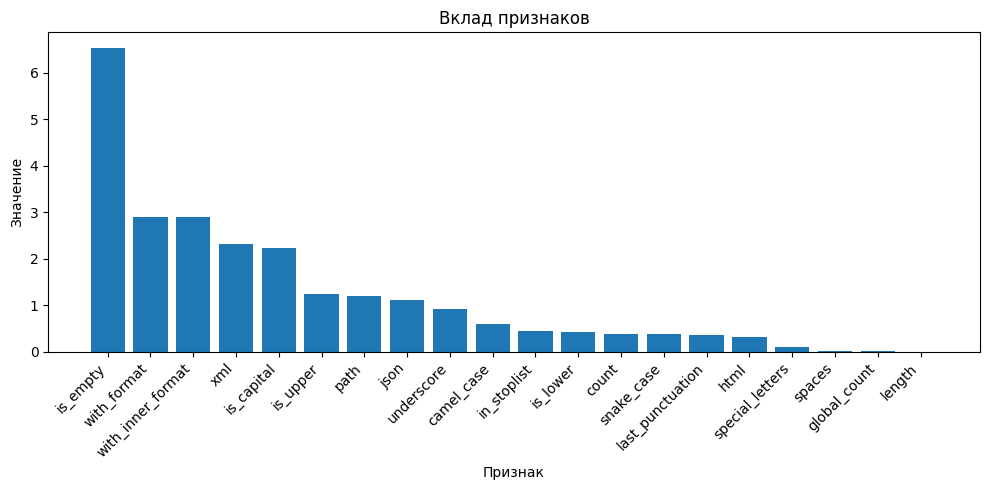

In [ ]:
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else [f'feature_{i}' for i in range(X_train.shape[1])]
coefs = clf.coef_[0]
importance = np.abs(coefs)

indices = np.argsort(importance)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(coefs)), importance[indices], align="center")
plt.xticks(range(len(coefs)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.ylabel('Значение')
plt.xlabel('Признак')
plt.title('Вклад признаков')
plt.tight_layout()
plt.show()

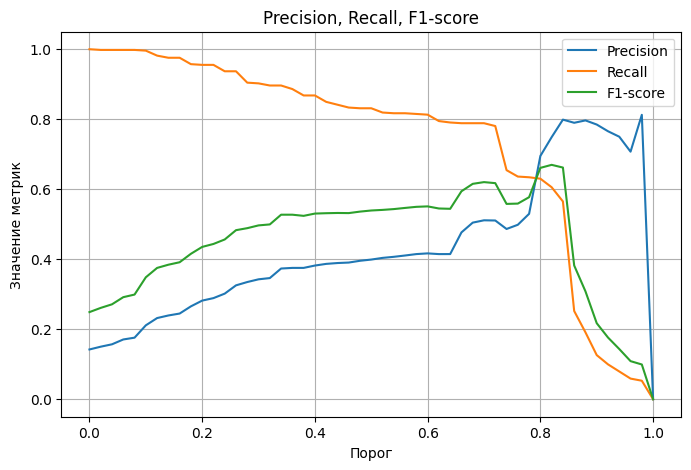

Best F1-score = 0.670 at threshold = 0.82


In [ ]:
thresholds = np.arange(0.0, 1.01, 0.02)
precisions, recalls, f1s = [], [], []

y_proba = clf.predict_proba(X_test)[:, 1]

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1-score')
plt.xlabel('Порог')
plt.ylabel('Значение метрик')
plt.title('Precision, Recall, F1-score')
plt.grid()
plt.legend()
plt.show()

best_threshold = thresholds[np.argmax(f1s)]
best_f1 = np.max(f1s)
print(f"Best F1-score = {best_f1:.3f} at threshold = {best_threshold:.2f}")

In [ ]:
cat_features = list(X_train.columns)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))


train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    class_weights=class_weights,
    eval_metric='F1',
    random_seed=42,
    verbose=50
)

model.fit(train_pool, eval_set=test_pool, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.9209142	test: 0.9063787	best: 0.9063787 (0)	total: 41.1ms	remaining: 20.5s
50:	learn: 0.9581917	test: 0.9488657	best: 0.9488657 (49)	total: 2.69s	remaining: 23.7s
100:	learn: 0.9648391	test: 0.9490358	best: 0.9502913 (65)	total: 5.4s	remaining: 21.3s
150:	learn: 0.9668117	test: 0.9490358	best: 0.9502913 (65)	total: 8.27s	remaining: 19.1s
200:	learn: 0.9697733	test: 0.9505692	best: 0.9514841 (194)	total: 10.4s	remaining: 15.5s
250:	learn: 0.9704424	test: 0.9516547	best: 0.9518254 (210)	total: 11.7s	remaining: 11.6s
300:	learn: 0.9730732	test: 0.9494814	best: 0.9518254 (210)	total: 12.9s	remaining: 8.52s
350:	learn: 0.9745304	test: 0.9486658	best: 0.9518254 (210)	total: 14.2s	remaining: 6.01s
400:	learn: 0.9769427	test: 0.9494162	best: 0.9518254 (210)	total: 15.5s	remaining: 3.82s
450:	learn: 0.9774833	test: 0.9482558	best: 0.9518254 (210)	total: 16.8s	remaining: 1.83s
499:	learn: 0.9792263	test: 0.9439312	best: 0.9518254 (210)	total: 18.9s	remaining: 0us

bestTest = 0.951825

Accuracy: 0.9664836752383704
Precision: 0.8455882352941176
Recall: 0.9349593495934959
F1: 0.888030888030888
ROC-AUC: 0.991111060908521
[[2885   84]
 [  32  460]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2969
           1       0.85      0.93      0.89       492

    accuracy                           0.97      3461
   macro avg       0.92      0.95      0.93      3461
weighted avg       0.97      0.97      0.97      3461



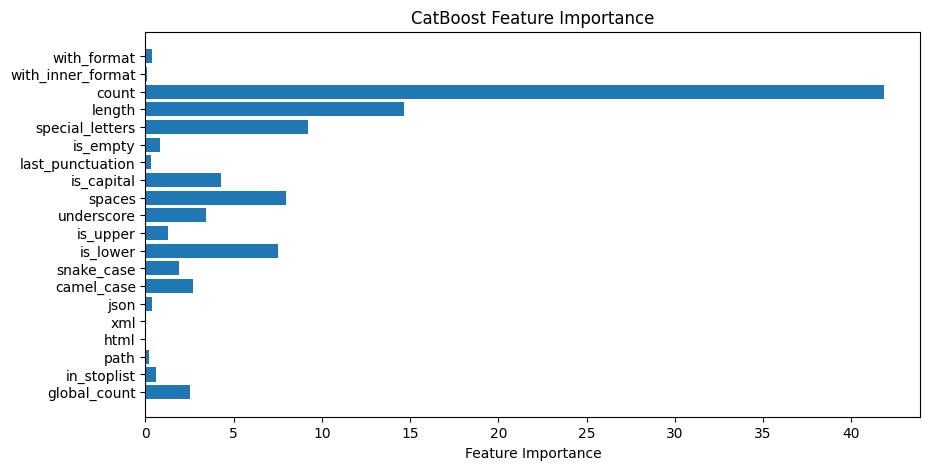

Best F1=0.896 at threshold=0.77


In [ ]:
# Предсказание
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Метрики
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Фиче-импортанс CatBoost


feat_imp = model.get_feature_importance()
plt.figure(figsize=(10,5))
plt.barh(cat_features, feat_imp)
plt.xlabel('Feature Importance')
plt.title('CatBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Важно: если хочешь поиграть с cut-off смотри пример ниже!

# Cut-off поиск
thresholds = np.arange(0.01, 1, 0.01)
f1s = []
for th in thresholds:
    preds_ = (y_proba >= th).astype(int)
    f1s.append(f1_score(y_test, preds_))
best_th = thresholds[np.argmax(f1s)]
print(f'Best F1={max(f1s):.3f} at threshold={best_th:.2f}')